### Load libraries

In [9]:
from importlib import reload
from helpers import *
from helpers.leverage import *
from helpers.portfolio import *
from helpers.stats import *
import pandas as pd
from pathlib import Path
from helpers.montecarlo import simulate_parametric, simulate_bootstrap, save_simulations_parquet
from helpers.portfolio import build_portfolios_from_prices
from helpers.leverage import leverage_backtest
import pandas as pd
from helpers.backtest import backtest_portfolio


from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
import pandas as pd



### Clustering

Found 68 tickers across 10 clusters


/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


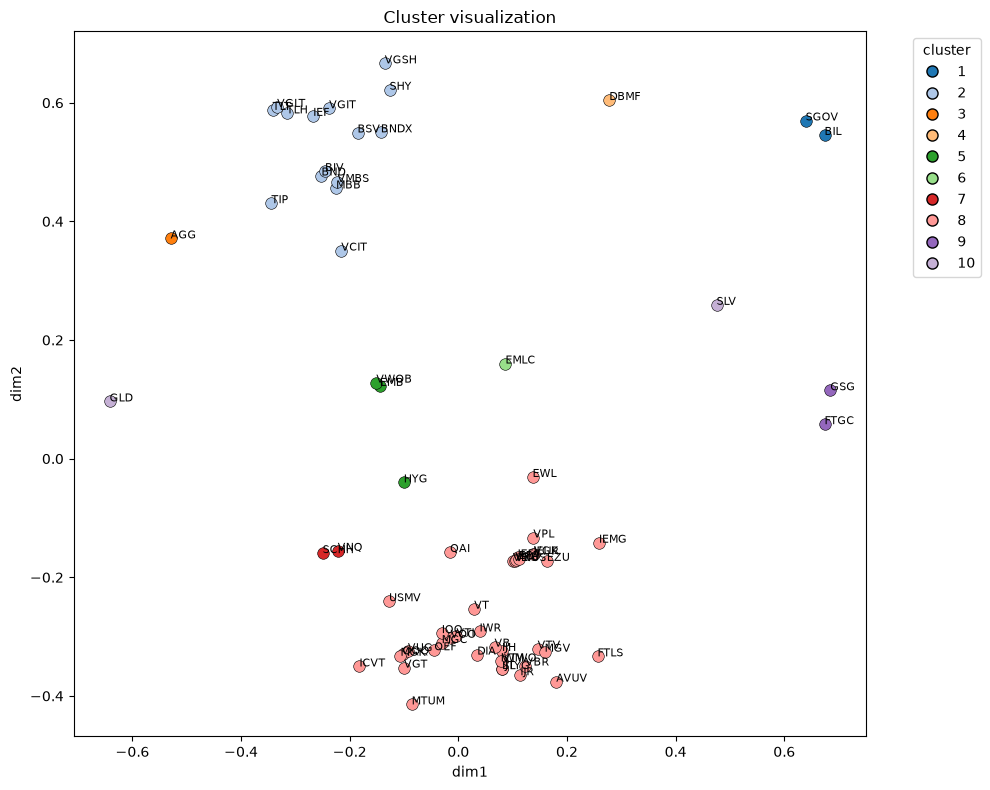

In [10]:
ETF_UNIVERSE_CSV_PATH = "data/etf_universe.csv"

# get clusters (and representatives) from the universe CSV
selected_tickers, clusters = cluster_select_representatives_from_csv(ETF_UNIVERSE_CSV_PATH, n_clusters=10)

print('Found', sum(len(v) for v in clusters.values()), 'tickers across', len(clusters), 'clusters')

# Build aligned price matrix for all tickers in the clusters (inner join on dates)
tickers = sorted([t for members in clusters.values() for t in members])
start_date = '2012-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
prices = pd.concat([load_data(t, start_date, end_date)['adj close'].rename(t) for t in tickers], axis=1, join='inner')
returns = prices.pct_change().dropna()

# Visualize clusters using the returns correlation (MDS embedding)
fig, ax = visualize_clusters(clusters, returns=returns)


### Common window / Optimization / Portfolio construction using the tickers from the clustering

In [11]:
# common window for selected_tickers tickers
min_window, max_window = common_window(selected_tickers)

start_date = "2012-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Min common start date:", min_window, "Max common end date:", max_window)

portfolios = build_portfolios(selected_tickers, start_date, end_date)

Min common start date: 2020-06-01 00:00:00 Max common end date: 2026-07-10 00:00:00


### Backtest with historical data using the weights given by optimization 

- min_variance
- equal_weight
- max_sharpe
- market_cap

<Axes: xlabel='date'>

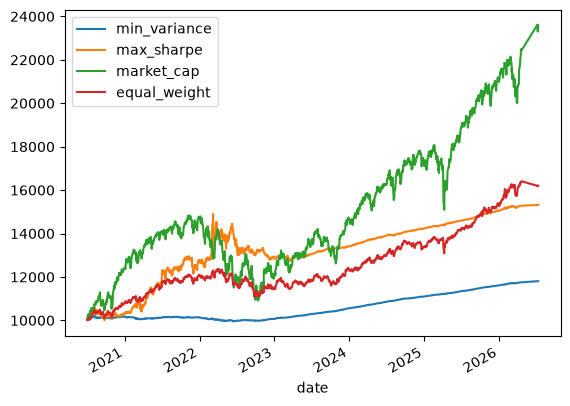

In [12]:
# Backtest with historical data (min-variance, max-sharpe, market-cap (VT), equal-weight)

# compute portfolio value series for each strategy
min_variance = backtest_portfolio(portfolios["min_variance"], start_value=10_000.0)
max_sharpe  = backtest_portfolio(portfolios["max_sharpe"],  start_value=10_000.0)
market_cap  = backtest_portfolio(portfolios["market_cap"],  start_value=10_000.0)
equal_weight = backtest_portfolio(portfolios["equal_weight"], start_value=10_000.0)

# merge into a single DataFrame for comparison
backtest_results = pd.concat(
    [
        min_variance.rename("min_variance"),
        max_sharpe.rename("max_sharpe"),
        market_cap.rename("market_cap"),
        equal_weight.rename("equal_weight"),
    ],
    axis=1,
)
backtest_results.plot()

### Monte Carlo Exports (Bootstrap, block size 10)

What you’ll run below:
- Unlevered simulations for all 4 strategies defined by `build_portfolios`, rebuilt on each simulated path.
- Leveraged simulations for the same 4 strategies using `leverage_backtest`.

Both use bootstrap resampling with block size 10 and save Parquet files locally for later analysis:
- Unlevered → `output/mc_values.parquet`
- Leveraged → `output/mc_leverage_values.parquet`

Tip: tune `n_days` (horizon) and `n_sims` (paths). Ensure `pyarrow` is installed for Parquet.


---

## Unleveraged portfolio optimization

In [ ]:
# Unlevered Monte Carlo (all 4 strategies) — bootstrap with block size 10
from pathlib import Path
import pandas as pd
from helpers.montecarlo import simulate_and_backtest_portfolios, save_simulations_parquet

# --- Configuration ---
n_days = 252 * 5      # simulation horizon (trading days)
n_sims = 5000        # number of paths to simulate (adjust as needed)
lookback_years = 3    # lookback used when rebuilding strategies on each path
block_size = 10       # moving-block bootstrap
seed = 1
start_value = 100_000.0
#---------------------------------------------------------------------------

#track execution time:
start_time = pd.Timestamp.now()


# Use the tickers already chosen upstream (from clustering). If absent, set a list manually.
try:
    tickers = list(dict.fromkeys(selected_tickers))  # preserve order, drop dups
except NameError:
    tickers = ["VTI", "IEF", "GLD", "VT"]

# --- Run simulations and backtests ---
values_unlevered = simulate_and_backtest_portfolios(
    tickers=tickers,
    n_days=n_days,
    n_sims=n_sims,
    lookback_years=lookback_years,
    block_size=block_size,
    seed=seed,
    method="bootstrap",
    start_value=start_value,
)

# --- Save to Parquet ---
out_unlev = Path("output/mc_values.parquet")
save_simulations_parquet(values_unlevered, str(out_unlev), engine="pyarrow")

# Preview from the first date where at least one strategy moves away from start_value
moved = values_unlevered.ne(start_value).any(axis=1)
first_moved_date = moved[moved].index.min()
values_unlevered.loc[first_moved_date:].head() if pd.notna(first_moved_date) else values_unlevered.head()

end_time = pd.Timestamp.now()
execution_time = end_time - start_time
print(f"Execution time: {execution_time}")

KeyboardInterrupt: 

## Leverage portfoio optimization

In [ ]:
# Leveraged Monte Carlo (all 4 strategies) — bootstrap with block size 10


#track execution time
start_time = pd.Timestamp.now()


# Leverage parameters (adjust as needed)
leverage = 2.0
lev_rebalance_freq_list = ["daily", "weekly", "monthly", None]  # None => band-based rebalancing
band = 0.1
hard_cap = 4.0
spread = 0.01

# Use selected tickers from earlier; ensure VT exists only for the market-cap benchmark returns
try:
    base_tickers = list(dict.fromkeys(selected_tickers))
except NameError:
    base_tickers = ["VTI", "IEF", "GLD"]

sim_tickers = base_tickers.copy()
if "VT" not in sim_tickers:
    sim_tickers.append("VT")

# Simulate return paths once (bootstrap, moving-block)
simulations = simulate_bootstrap(
    sim_tickers,
    n_days=n_days,
    n_sims=n_sims,
    lookback_years=lookback_years,
    block_size=block_size,
    seed=seed,
)

for lev_rebalance_freq in lev_rebalance_freq_list:
    strategies = ["min_variance", "max_sharpe", "market_cap", "equal_weight"]
    all_values = []

    for i, sim in enumerate(simulations, start=1):
        # Business-day index for calendar-aware rebalancing
        idx = pd.bdate_range(start=pd.Timestamp("2000-01-03"), periods=sim.shape[0])
        effr = sim["EFFR"].copy() if "EFFR" in sim.columns else None
        if effr is not None:
            effr.index = idx
        rets = sim.drop(columns=["EFFR"], errors="ignore").copy()
        rets.index = idx

        # Build optimized/equal-weight strategies only on selected tickers.
        # VT remains available in returns for the market_cap benchmark.
        prices = (1.0 + rets[base_tickers]).cumprod()
        weights = build_portfolios_from_prices(
            prices=prices,
            start=prices.index.min(),
            end=prices.index.max(),
            lookback_years=lookback_years,
            freq="BMS",
        )

        for strategy in strategies:
            W = weights[strategy]
            lev_df = leverage_backtest(
                W,
                leverage=leverage,
                start_value=start_value,
                returns=rets,
                effr=effr,
                freq=lev_rebalance_freq,
                band=band,
                hard_cap=hard_cap,
                spread=spread,
            )
            all_values.append(lev_df["portfolio_value"].rename((i, strategy)))

    values_lev = pd.concat(all_values, axis=1)
    values_lev.columns = pd.MultiIndex.from_tuples(values_lev.columns, names=["sim", "strategy"])
    values_lev.index.name = "date"

    tag = lev_rebalance_freq if lev_rebalance_freq else "band"
    out_lev = Path(f"output/mc_leverage_values_{tag}.parquet")
    save_simulations_parquet(values_lev, str(out_lev), engine="pyarrow")

# Preview monthly results from the first date where at least one strategy moves away from start_value
monthly_values = pd.read_parquet("output/mc_leverage_values_monthly.parquet", engine="pyarrow")
moved = monthly_values.ne(start_value).any(axis=1)
first_moved_date = moved[moved].index.min()
monthly_values.loc[first_moved_date:].head() if pd.notna(first_moved_date) else monthly_values.head()

end_time = pd.Timestamp.now()
execution_time = end_time - start_time
print(f"Execution time: {execution_time}")

Execution time: 0 days 05:45:38.078024


### Analysis of Unleveraged

,min_variance,max_sharpe,market_cap,equal_weight
q01,121793.000,121306.000,119361.000,128910.000
q10,124461.000,128579.000,162569.000,145933.000
q25,125973.000,133024.000,197140.000,157832.000
q50,127659.000,139335.000,243600.000,172121.000
q75,129318.000,147072.000,297564.000,187495.000
q90,130926.000,154960.000,358011.000,201629.000
q99,133510.000,175426.000,481215.000,228140.000
mean,127673.000,140902.000,253735.000,173158.000
min,119319.000,111618.000,72592.000,101829.000
max,138908.000,204397.000,693568.000,258801.000


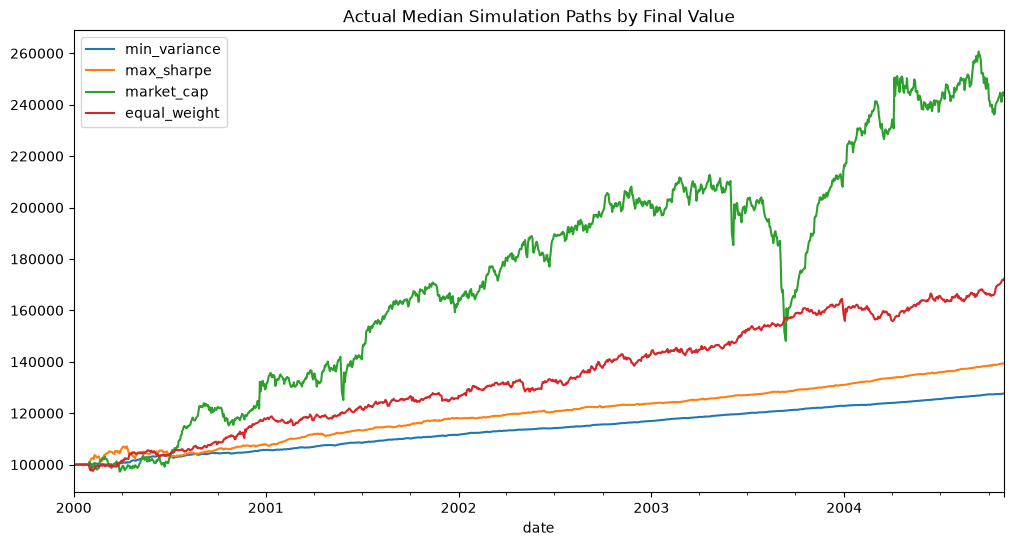

In [ ]:
# Read unlevered Monte Carlo Parquet and extract strategy paths
unleveraged = pd.read_parquet("output/mc_values.parquet", engine="pyarrow")
sims_mv = unleveraged.xs("min_variance", level="strategy", axis=1)
sims_ms = unleveraged.xs("max_sharpe", level="strategy", axis=1)
sims_mc = unleveraged.xs("market_cap", level="strategy", axis=1)
sims_ew = unleveraged.xs("equal_weight", level="strategy", axis=1)

def median_simulation_path(strategy_sims: pd.DataFrame) -> pd.Series:
    final_values = strategy_sims.iloc[-1]
    median_final_value = final_values.median()
    median_sim = (final_values - median_final_value).abs().idxmin()
    return strategy_sims[median_sim].rename(median_sim)

median_paths = pd.DataFrame({
    "min_variance": median_simulation_path(sims_mv),
    "max_sharpe": median_simulation_path(sims_ms),
    "market_cap": median_simulation_path(sims_mc),
    "equal_weight": median_simulation_path(sims_ew),
})

median_paths.plot(title="Actual Median Simulation Paths by Final Value", figsize=(12, 6))

#QUANTILES FOR EACH STRATEGY, COMBINED DF
quantiles_unlevered = pd.concat([
    quantiles_df(sims_mv),
    quantiles_df(sims_ms),
    quantiles_df(sims_mc),
    quantiles_df(sims_ew)
], axis=1, keys=["min_variance", "max_sharpe", "market_cap", "equal_weight"])
quantiles_unlevered

In [ ]:
leveraged_daily = pd.read_parquet("output/mc_leverage_values_daily.parquet", engine="pyarrow")

sims_mv_lev_daily = leveraged_daily.xs("min_variance", level="strategy", axis=1)
sims_ms_lev_daily = leveraged_daily.xs("max_sharpe", level="strategy", axis=1)
sims_mc_lev_daily = leveraged_daily.xs("market_cap", level="strategy", axis=1)
sims_ew_lev_daily = leveraged_daily.xs("equal_weight", level="strategy", axis=1)

median_paths_lev_daily = pd.DataFrame({
    "min_variance": median_simulation_path(sims_mv_lev_daily),
    "max_sharpe": median_simulation_path(sims_ms_lev_daily),
    "market_cap": median_simulation_path(sims_mc_lev_daily),
    "equal_weight": median_simulation_path(sims_ew_lev_daily),
})

quantiles_lev_daily = pd.concat([
    quantiles_df(sims_mv_lev_daily),
    quantiles_df(sims_ms_lev_daily),
    quantiles_df(sims_mc_lev_daily),    
    quantiles_df(sims_ew_lev_daily)
], axis=1, keys=["min_variance", "max_sharpe", "market_cap", "equal_weight"])

quantiles_lev_daily


,min_variance,max_sharpe,market_cap,equal_weight
q01,121567.000,120084.000,104208.000,133675.000
q10,126933.000,135243.000,194014.000,171223.000
q25,130093.000,144628.000,287655.000,200459.000
q50,133572.000,158598.000,438722.000,238151.000
q75,137083.000,176596.000,658179.000,283043.000
q90,140438.000,195809.000,949288.000,327138.000
q99,145921.000,250596.000,1732828.000,419236.000
mean,133641.000,163165.000,522504.000,244949.000
min,116644.000,101602.000,38849.000,82868.000
max,158027.000,339214.000,3573241.000,537334.000


### Lev weekly

In [ ]:
leveraged_week = pd.read_parquet("output/mc_leverage_values_weekly.parquet", engine="pyarrow")

sims_mv_lev_week = leveraged_week.xs("min_variance", level="strategy", axis=1)
sims_ms_lev_week = leveraged_week.xs("max_sharpe", level="strategy", axis=1)
sims_mc_lev_week = leveraged_week.xs("market_cap", level="strategy", axis=1)
sims_ew_lev_week = leveraged_week.xs("equal_weight", level="strategy", axis=1)

median_paths_lev_week = pd.DataFrame({
    "min_variance": median_simulation_path(sims_mv_lev_week),
    "max_sharpe": median_simulation_path(sims_ms_lev_week),
    "market_cap": median_simulation_path(sims_mc_lev_week),
    "equal_weight": median_simulation_path(sims_ew_lev_week),
})

quantiles_lev_week = pd.concat([
    quantiles_df(sims_mv_lev_week),
    quantiles_df(sims_ms_lev_week),
    quantiles_df(sims_mc_lev_week),    
    quantiles_df(sims_ew_lev_week)
], axis=1, keys=["min_variance", "max_sharpe", "market_cap", "equal_weight"])

quantiles_lev_week

### Lev monthly

In [ ]:
leveraged_monthly = pd.read_parquet("output/mc_leverage_values_monthly.parquet", engine="pyarrow")

sims_mv_lev_monthly = leveraged_monthly.xs("min_variance", level="strategy", axis=1)
sims_ms_lev_monthly = leveraged_monthly.xs("max_sharpe", level="strategy", axis=1)
sims_mc_lev_monthly = leveraged_monthly.xs("market_cap", level="strategy", axis=1)
sims_ew_lev_monthly = leveraged_monthly.xs("equal_weight", level="strategy", axis=1)

median_paths_lev_monthly = pd.DataFrame({
    "min_variance": median_simulation_path(sims_mv_lev_monthly),
    "max_sharpe": median_simulation_path(sims_ms_lev_monthly),
    "market_cap": median_simulation_path(sims_mc_lev_monthly),
    "equal_weight": median_simulation_path(sims_ew_lev_monthly),
})

quantiles_lev_monthly = pd.concat([
    quantiles_df(sims_mv_lev_monthly),
    quantiles_df(sims_ms_lev_monthly),
    quantiles_df(sims_mc_lev_monthly),    
    quantiles_df(sims_ew_lev_monthly)
], axis=1, keys=["min_variance", "max_sharpe", "market_cap", "equal_weight"])

quantiles_lev_monthly

,min_variance,max_sharpe,market_cap,equal_weight
q01,121540.000,120283.000,104514.000,133663.000
q10,126950.000,135381.000,195658.000,171596.000
q25,130106.000,144712.000,288553.000,200674.000
q50,133583.000,158629.000,441114.000,238443.000
q75,137088.000,176497.000,658313.000,282713.000
q90,140433.000,195630.000,941383.000,326952.000
q99,145898.000,249894.000,1688498.000,419032.000
mean,133642.000,163145.000,521181.000,245035.000
min,116602.000,100370.000,38522.000,82885.000
max,157920.000,335704.000,3372850.000,535902.000


### Lev band

In [ ]:
leveraged_band = pd.read_parquet("output/mc_leverage_values_band.parquet", engine="pyarrow")

sims_mv_lev_band = leveraged_band.xs("min_variance", level="strategy", axis=1)
sims_ms_lev_band = leveraged_band.xs("max_sharpe", level="strategy", axis=1)
sims_mc_lev_band = leveraged_band.xs("market_cap", level="strategy", axis=1)
sims_ew_lev_band = leveraged_band.xs("equal_weight", level="strategy", axis=1)

median_paths_lev_band = pd.DataFrame({
    "min_variance": median_simulation_path(sims_mv_lev_band),
    "max_sharpe": median_simulation_path(sims_ms_lev_band),
    "market_cap": median_simulation_path(sims_mc_lev_band),
    "equal_weight": median_simulation_path(sims_ew_lev_band),
})

quantiles_lev_band = pd.concat([
    quantiles_df(sims_mv_lev_band),
    quantiles_df(sims_ms_lev_band),
    quantiles_df(sims_mc_lev_band),    
    quantiles_df(sims_ew_lev_band)
], axis=1, keys=["min_variance", "max_sharpe", "market_cap", "equal_weight"])

quantiles_lev_band

,min_variance,max_sharpe,market_cap,equal_weight
q01,121648.000,120517.000,104567.000,133598.000
q10,126948.000,135257.000,192694.000,170940.000
q25,130020.000,144062.000,284306.000,198481.000
q50,133368.000,157132.000,429717.000,233729.000
q75,136700.000,174339.000,634755.000,275583.000
q90,139859.000,192015.000,909381.000,316350.000
q99,144944.000,243010.000,1602242.000,399544.000
mean,133381.000,161407.000,504866.000,239885.000
min,116680.000,101373.000,39114.000,83232.000
max,156138.000,324709.000,3104947.000,507380.000
